In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df = pd.read_excel(r"/content/Afficionado Coffee Roasters.xlsx")
df.head()

,transaction_id,year,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2025,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2025,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2025,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2025,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2025,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   transaction_id    149116 non-null  int64  
 1   year              149116 non-null  int64  
 2   transaction_time  149116 non-null  object 
 3   transaction_qty   149116 non-null  int64  
 4   store_id          149116 non-null  int64  
 5   store_location    149116 non-null  object 
 6   product_id        149116 non-null  int64  
 7   unit_price        149116 non-null  float64
 8   product_category  149116 non-null  object 
 9   product_type      149116 non-null  object 
 10  product_detail    149116 non-null  object 
dtypes: float64(1), int64(5), object(5)
memory usage: 12.5+ MB


,transaction_id,year,transaction_qty,store_id,product_id,unit_price
count,149116.000000,149116.0,149116.000000,149116.000000,149116.000000,149116.000000
mean,74737.371872,2025.0,1.438276,5.342063,47.918607,3.382219
std,43153.600016,0.0,0.542509,2.074241,17.930020,2.658723
min,1.000000,2025.0,1.000000,3.000000,1.000000,0.800000
25%,37335.750000,2025.0,1.000000,3.000000,33.000000,2.500000
50%,74727.500000,2025.0,1.000000,5.000000,47.000000,3.000000
75%,112094.250000,2025.0,2.000000,8.000000,60.000000,3.750000
max,149456.000000,2025.0,8.000000,8.000000,87.000000,45.000000


# **Data Cleaning**

In [ ]:
df = df.dropna()
df = df[df["transaction_qty"] > 0]
df = df[df["unit_price"] > 0]

In [ ]:
import datetime as dt

transaction_year = df['year'].iloc[0]
df['transaction_time'] = df['transaction_time'].apply(
    lambda time_obj: dt.datetime.combine(dt.date(transaction_year, 1, 1), time_obj)
)

# **Revenue Calculation**

In [ ]:
df["revenue"] = df["transaction_qty"] * df["unit_price"]

df.head()

,transaction_id,year,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,revenue
0,1,2025,2025-01-01 07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,6.0
1,2,2025,2025-01-01 07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2
2,3,2025,2025-01-01 07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,9.0
3,4,2025,2025-01-01 07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,2.0
4,5,2025,2025-01-01 07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2


# **Basic Business Metrics**

In [ ]:
total_revenue = df["revenue"].sum()
total_transactions = df["transaction_id"].nunique()
total_units = df["transaction_qty"].sum()

print("Total Revenue:", total_revenue)
print("Total Transactions:", total_transactions)
print("Total Units Sold:", total_units)

Total Revenue: 698812.3300000002
Total Transactions: 149116
Total Units Sold: 214470


# **Product Popularity Analysis (Sales Volume)**

In [ ]:
product_sales = df.groupby("product_detail")["transaction_qty"].sum().sort_values(ascending=False)

print(product_sales.head(10))

product_detail
Earl Grey Rg                   4708
Dark chocolate Lg              4668
Morning Sunrise Chai Rg        4643
Latte                          4602
Peppermint Rg                  4564
Columbian Medium Roast Rg      4547
Traditional Blend Chai Rg      4512
Latte Rg                       4497
Our Old Time Diner Blend Sm    4484
Serenity Green Tea Rg          4477
Name: transaction_qty, dtype: int64


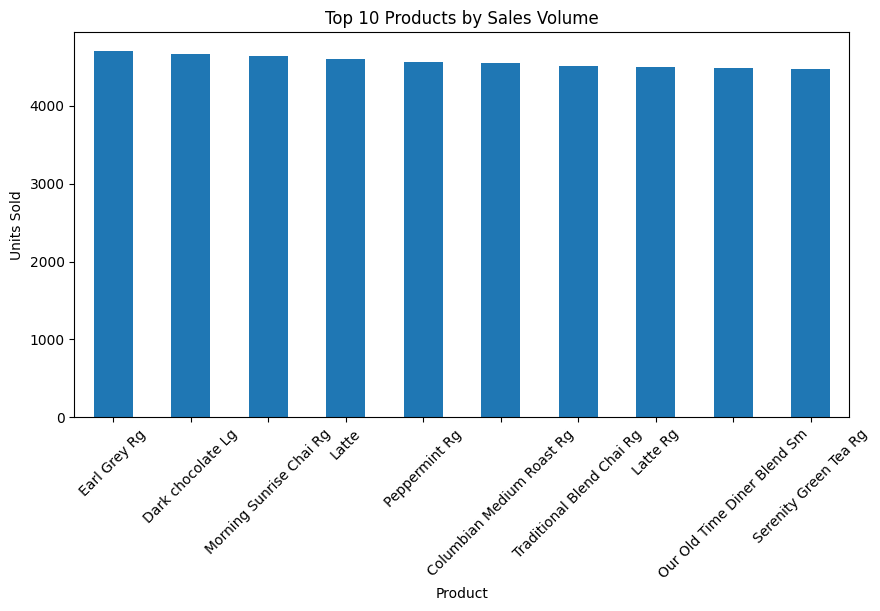

In [ ]:
top_products = product_sales.head(10)

top_products.plot(kind="bar", figsize=(10,5))
plt.title("Top 10 Products by Sales Volume")
plt.xlabel("Product")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.show()

# **Revenue Contribution by Product**

In [ ]:
product_revenue = df.groupby("product_detail")["revenue"].sum().sort_values(ascending=False)

print(product_revenue.head(10))

product_detail
Sustainably Grown Organic Lg    21151.75
Dark chocolate Lg               21006.00
Latte Rg                        19112.25
Cappuccino Lg                   17641.75
Morning Sunrise Chai Lg         17384.00
Latte                           17257.50
Jamaican Coffee River Lg        16481.25
Sustainably Grown Organic Rg    16233.75
Cappuccino                      15997.50
Brazilian Lg                    15109.50
Name: revenue, dtype: float64


# **Category Revenue Distribution**

In [ ]:
category_revenue = df.groupby("product_category")["revenue"].sum().sort_values(ascending=False)

print(category_revenue)

product_category
Coffee                269952.45
Tea                   196405.95
Bakery                 82315.64
Drinking Chocolate     72416.00
Coffee beans           40085.25
Branded                13607.00
Loose Tea              11213.60
Flavours                8408.80
Packaged Chocolate      4407.64
Name: revenue, dtype: float64


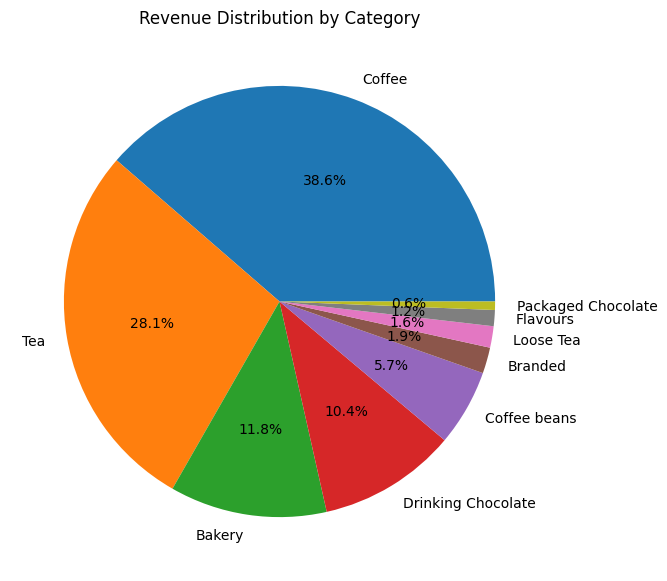

In [ ]:
plt.figure(figsize=(7,7))
category_revenue.plot(kind="pie", autopct='%1.1f%%')
plt.title("Revenue Distribution by Category")
plt.ylabel("")
plt.show()

# **Product Type Performance**

In [ ]:
type_revenue = df.groupby("product_type")["revenue"].sum().sort_values(ascending=False)

print(type_revenue.head(10))

product_type
Barista Espresso         91406.20
Brewed Chai tea          77081.95
Hot chocolate            72416.00
Gourmet brewed coffee    70034.60
Brewed Black tea         47932.00
Brewed herbal tea        47539.50
Premium brewed coffee    38781.15
Organic brewed coffee    37746.50
Scone                    36866.12
Drip coffee              31984.00
Name: revenue, dtype: float64


# **Store Location Performance**

In [ ]:
store_revenue = df.groupby("store_location")["revenue"].sum()

print(store_revenue)

store_location
Astoria            232243.91
Hell's Kitchen     236511.17
Lower Manhattan    230057.25
Name: revenue, dtype: float64


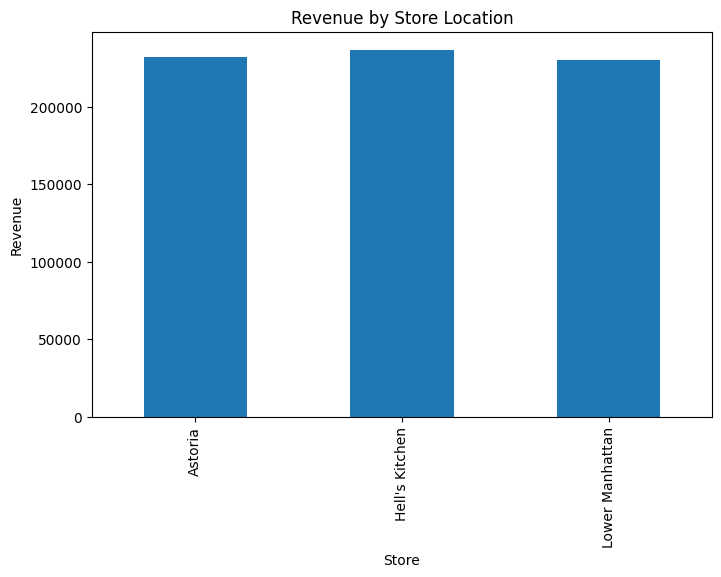

In [ ]:
store_revenue.plot(kind="bar", figsize=(8,5))
plt.title("Revenue by Store Location")
plt.xlabel("Store")
plt.ylabel("Revenue")
plt.show()

# **Popularity vs Revenue Analysis**

In [ ]:
product_analysis = df.groupby("product_detail").agg(
    units_sold=("transaction_qty", "sum"),
    revenue=("revenue", "sum")
).reset_index()

product_analysis.head()

,product_detail,units_sold,revenue
0,Almond Croissant,1911,7168.13
1,Brazilian - Organic,214,3852.00
2,Brazilian Lg,4317,15109.50
3,Brazilian Rg,4385,13155.00
4,Brazilian Sm,4310,9482.00


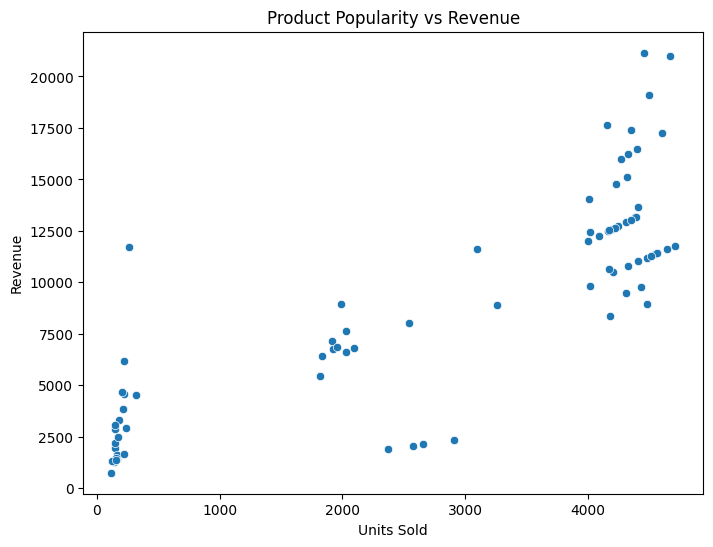

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=product_analysis, x="units_sold", y="revenue")

plt.title("Product Popularity vs Revenue")
plt.xlabel("Units Sold")
plt.ylabel("Revenue")
plt.show()

# **Pareto Analysis (80/20 Rule)**

In [ ]:
pareto = product_revenue.reset_index()

pareto["cumulative_revenue"] = pareto["revenue"].cumsum()
pareto["cumulative_percentage"] = 100 * pareto["cumulative_revenue"] / pareto["revenue"].sum()

pareto.head()

,product_detail,revenue,cumulative_revenue,cumulative_percentage
0,Sustainably Grown Organic Lg,21151.75,21151.75,3.026814
1,Dark chocolate Lg,21006.00,42157.75,6.032771
2,Latte Rg,19112.25,61270.00,8.767733
3,Cappuccino Lg,17641.75,78911.75,11.292266
4,Morning Sunrise Chai Lg,17384.00,96295.75,13.779916


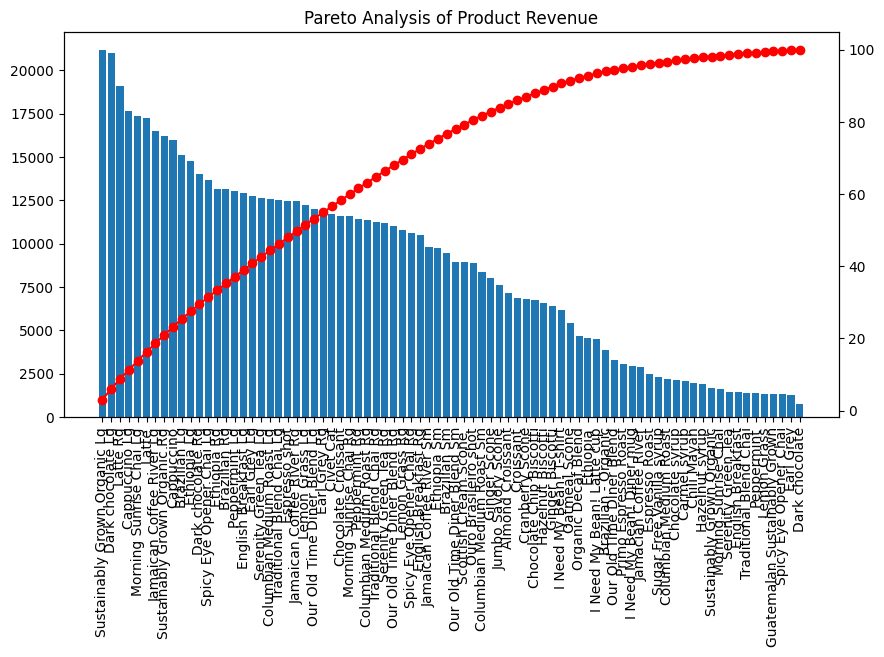

In [ ]:
plt.figure(figsize=(10,5))

plt.bar(pareto["product_detail"], pareto["revenue"])
plt.xticks(rotation=90)

plt.twinx()
plt.plot(pareto["product_detail"], pareto["cumulative_percentage"], color="red", marker="o")

plt.title("Pareto Analysis of Product Revenue")
plt.show()

# **Product Efficiency Score**

In [ ]:
product_analysis["efficiency_score"] = product_analysis["revenue"] / product_analysis["units_sold"]

product_analysis.sort_values("efficiency_score", ascending=False).head()

,product_detail,units_sold,revenue,efficiency_score
12,Civet Cat,260,11700.0,45.000000
41,I Need My Bean! T-shirt,221,6163.0,27.886878
56,Organic Decaf Blend,206,4657.5,22.609223
30,Ethiopia,218,4578.0,21.000000
65,Primo Espresso Roast,150,3067.5,20.450000


In [ ]:
df.to_csv("cleaned_coffee_sales.csv", index=False)